In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import regex as re
import nltk
from nltk.tokenize import sent_tokenize , word_tokenize
from collections import Counter
import spacy
import networkx as nx
from gensim import corpora , models
import joblib

In [60]:
files = [
    "data/001ssb.txt",
    "data/002ssb.txt",
    "data/003ssb.txt",
    "data/004ssb.txt",
    "data/005ssb.txt",
]

text = ""

for file in files:
    with open(file, "r", encoding="latin-1") as f:
        text += f.read() + "\n"

In [61]:
len(text)

9778338

In [62]:
text[:1000]

'A Game Of Thrones \nBook One of A Song of Ice and Fire \nBy George R. R. Martin \nPROLOGUE \n"We should start back," Gared urged as the woods began to grow dark around them. "The wildlings are \ndead." \n"Do the dead frighten you?" Ser Waymar Royce asked with just the hint of a smile. \nGared did not rise to the bait. He was an old man, past fifty, and he had seen the lordlings come and go. \n"Dead is dead," he said. "We have no business with the dead." \n"Are they dead?" Royce asked softly. "What proof have we?" \n"Will saw them," Gared said. "If he says they are dead, that\'s proof enough for me." \nWill had known they would drag him into the quarrel sooner or later. He wished it had been later rather \nthan sooner. "My mother told me that dead men sing no songs," he put in. \n"My wet nurse said the same thing, Will," Royce replied. "Never believe anything you hear at a woman\'s \ntit. There are things to be learned even from the dead." His voice echoed, too loud in the twilit fores

# **Text Preprocessing**

In [63]:
def preprocess(text):

    text = text.lower()
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text


clean_text = preprocess(text)

In [64]:
joblib.dump(preprocess, "models/clean_text.joblib")

['models/clean_text.joblib']

# **Sentence Tokenizer**

In [65]:
# sentence = sent_tokenize(text)
# sentence[:10]

In [66]:
# text = re.sub(r'[^a-zA-Z\s]' , '' , text)

# **Word Tokenizer**

In [67]:
tokens = word_tokenize(text)

In [68]:
tokens[:30]

['A',
 'Game',
 'Of',
 'Thrones',
 'Book',
 'One',
 'of',
 'A',
 'Song',
 'of',
 'Ice',
 'and',
 'Fire',
 'By',
 'George',
 'R.',
 'R.',
 'Martin',
 'PROLOGUE',
 "''",
 'We',
 'should',
 'start',
 'back',
 ',',
 "''",
 'Gared',
 'urged',
 'as',
 'the']

In [69]:
joblib.dump(tokens, "models/tokens.joblib")

['models/tokens.joblib']

# **Token Frequency**

In [70]:
freq = Counter(tokens)

print(freq.most_common(50))

[('.', 133479), (',', 126836), ('the', 88167), ('and', 49121), ('to', 39536), ('of', 37348), ('a', 36732), ("''", 28766), ('``', 28063), ('his', 23947), ('was', 22054), ('he', 19263), ('I', 18905), ('her', 17814), ('in', 17275), ('had', 16982), ('you', 15634), ('The', 14363), ('that', 14322), ('as', 13995), ('?', 13033), ('with', 12933), ('it', 12827), ('him', 12273), ('not', 11476), ("'s", 11049), ('for', 10245), ('she', 10238), ('but', 9633), ('He', 9405), ('said', 8718), ('is', 8645), ('on', 8585), ('at', 8358), ('have', 8356), ('\x94', 8054), ('be', 7871), ('them', 7713), ('from', 7109), ('were', 7005), ('would', 6932), ('my', 6896), ('they', 6747), ('me', 6660), ('will', 5817), ('all', 5565), ('no', 5533), ('one', 5356), ('Lord', 5173), ('could', 5103)]


In [71]:
joblib.dump(freq, "models/word_freq.joblib")

['models/word_freq.joblib']

# **Named Entity Recognization**

In [72]:
len(text)

9778338

In [73]:
nlp = spacy.load("en_core_web_sm") 

doc = nlp(text[:100000])

character = []

for ent in doc.ents:
    if ent.label_ == "PERSON":
        character.append(ent.text)

print(set(character))

{'Kingslayer', 'Your Grace', 'Robert Arryn', 'Drogo', 'Hoster Tully', 'Ned', 'Lady Stark', 'Sansa', 'Jon Snow', 'Joffrey \nBaratheon', 'Benjen Stark', 'fond', 'Catelyn Tully', 'Absurd', 'Grace', 'Theon Greyjoy', 'Kingsguard', 'Maester Luwin', 'Desmond', 'Brynden', 'Catelyn', 'Ben', 'Tywin', 'Joffrey', 'House Stark', 'Jon Arryn', 'Lannister', 'Dorne', 'Redwyne', 'Illyrio', 'Rickon', 'Viserys', 'Snow', 'knelt', 'Hullen', 'Robb', 'Jaime', 'Doom', 'Dothraki', 'Greyjoy', 'Illyrio Mopatis', 'Khal Drogo', 'Lion', 'Eddard Stark', 'Lyanna', 'Queen Cersei', 'Darry', 'Cersei', 'Princess Daenerys', 'Usurper', "Khal Drogo's", 'Rhaegar', 'Lys', 'Robert Baratheon', 'a Stark of Winterfell', 'Old Nan', 'bush', 'Bran', 'Robert grasped Ned', 'grey', 'wolf', 'Arryn', 'Sandor Clegane', 'My Joff', 'Ser Waymar Royce', 'Jaime Lannister', 'Waymar', 'gaunt', 'Volantis', "Ser Rodrik's", 'Jory', 'Dany', 'Ser Jorah Mormont', 'Stark', 'Jon', 'Waymar Royce', 'Jory Cassel', 'Robert muttered', 'Ned knelt', 'Dragonlord

In [74]:
joblib.dump(nlp, "models/spacy_model.joblib")

['models/spacy_model.joblib']

# **Character Graph**

In [75]:
import itertools

def build_character_network(text, nlp):

    doc = nlp(text)

    G = nx.Graph()

    for sent in doc.sents:

        characters = [
            ent.text
            for ent in sent.ents
            if ent.label_ == "PERSON"
        ]

        for pair in itertools.combinations(set(characters), 2):

            if G.has_edge(*pair):
                G[pair[0]][pair[1]]["weight"] += 1
            else:
                G.add_edge(pair[0], pair[1], weight=1)

    return G

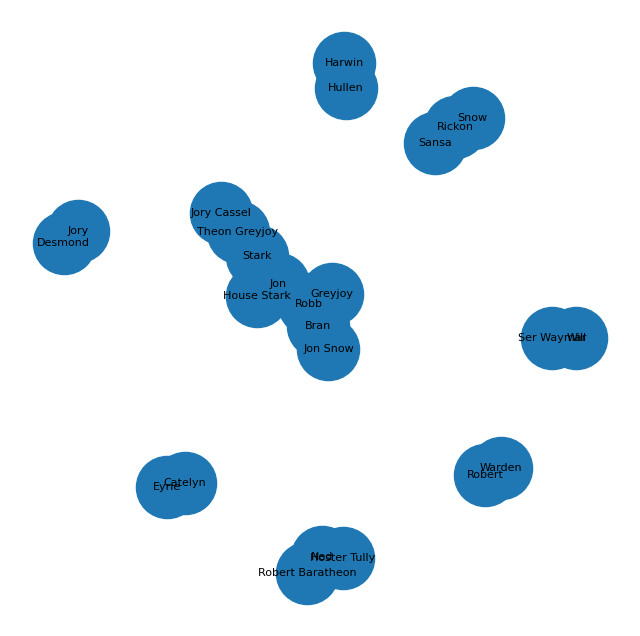

In [77]:
G = build_character_network(text[:50000], nlp)

fig, ax = plt.subplots(figsize=(8,8))

nx.draw(
    G,
    with_labels=True,
    node_size=2000,
    font_size=8
)

In [78]:
joblib.dump(G, "models/character_graph.joblib")

['models/character_graph.joblib']

# **LDA (Latent Dirichlet Allocation)**

In [79]:
dictionary = corpora.Dictionary([tokens])
corpus = [dictionary.doc2bow(tokens)]

lda = models.LdaModel(corpus=corpus , num_topics=5 , id2word=dictionary)

lda.print_topics()

[(0,
  '0.062*"," + 0.060*"." + 0.042*"the" + 0.020*"and" + 0.019*"to" + 0.019*"a" + 0.018*"of" + 0.014*"``" + 0.013*"\'\'" + 0.010*"his"'),
 (1,
  '0.048*"." + 0.046*"," + 0.040*"the" + 0.020*"and" + 0.019*"to" + 0.013*"a" + 0.013*"``" + 0.011*"\'\'" + 0.011*"of" + 0.011*"he"'),
 (2,
  '0.041*"." + 0.038*"," + 0.036*"the" + 0.028*"to" + 0.017*"and" + 0.015*"of" + 0.013*"a" + 0.011*"``" + 0.010*"\'\'" + 0.010*"he"'),
 (3,
  '0.071*"." + 0.056*"," + 0.042*"the" + 0.025*"and" + 0.019*"of" + 0.016*"to" + 0.015*"a" + 0.014*"\'\'" + 0.012*"was" + 0.012*"``"'),
 (4,
  '0.063*"," + 0.049*"." + 0.035*"the" + 0.024*"and" + 0.019*"a" + 0.018*"to" + 0.014*"\'\'" + 0.014*"of" + 0.014*"his" + 0.013*"``"')]

In [80]:
joblib.dump(lda, "models/lda_model.joblib")
joblib.dump(dictionary, "models/lda_dictionary.joblib")

['models/lda_dictionary.joblib']

In [81]:
from transformers import GPT2Tokenizer , GPT2LMHeadModel

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

In [82]:
# from transformers import AutoTokenizer, AutoModelForCausalLM

# tokenizer = AutoTokenizer.from_pretrained("distilgpt2")
# model = AutoModelForCausalLM.from_pretrained("distilgpt2")

In [83]:
prompt = "The night was cold and the wall stood silent"

inputs = tokenizer.encode(prompt, return_tensors="pt")

output = model.generate(
    inputs,
    max_length=100,
    num_return_sequences=1,
    temperature=0.8,
    do_sample=True
)

generated_text = tokenizer.decode(output[0], skip_special_tokens=True)

print(generated_text)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The night was cold and the wall stood silent. The man in the glasses watched the room, and he was certain that it had been there for some time. He had seen that the room looked different, and it was now almost as if it had been here for an eternity. The man in the glasses shook his head. "No, it doesn't," he said, "it's in the night."

He had been in prison a few years before now. He had been part of


In [85]:
model.save_pretrained("models/gpt2")
tokenizer.save_pretrained("models/gpt2")

('models/gpt2\\tokenizer_config.json',
 'models/gpt2\\special_tokens_map.json',
 'models/gpt2\\vocab.json',
 'models/gpt2\\merges.txt',
 'models/gpt2\\added_tokens.json')